In [3]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd


In [4]:
model = pd.read_csv("aggregated_postcode_level_data.csv")

In [5]:
model.head()

,postcode_district,sale_year,average_price,median_price,number_of_sale,average_newly_build,average_freehold,average_post_covid,average_log_floor_area,average_log_habitable_rooms,average_log_floor_area_per_room,average_property_age,average_energy_rating,percentage_of_large_property,epc_ptype_Bungalow,epc_ptype_Flat,epc_ptype_House,epc_ptype_Maisonette,epc_ptype_Park home,number_of_epc
0,BR6,2021,790590.909091,756000.0,11,0.000000,1.000000,1.0,4.667847,1.815756,3.089596,101.000000,2.818182,0.0,0.272727,0.000000,0.727273,0.000000,0.0,11.0
1,BR6,2022,760285.714286,718000.0,7,0.000000,1.000000,1.0,5.145853,1.901261,3.443089,89.000000,3.666667,0.0,0.000000,0.000000,1.000000,0.000000,0.0,3.0
2,BR6,2023,626600.000000,587000.0,5,0.000000,1.000000,1.0,5.042706,2.012507,3.217430,56.111111,3.000000,0.0,0.222222,0.000000,0.777778,0.000000,0.0,9.0
3,BR6,2024,792500.000000,792500.0,2,0.000000,1.000000,1.0,4.898109,1.823254,3.284665,96.250000,3.500000,0.0,0.250000,0.000000,0.750000,0.000000,0.0,4.0
4,BR8,2021,403978.901602,371500.0,437,0.020595,0.878719,1.0,4.238386,1.489398,3.060780,53.444444,4.205556,0.0,0.061111,0.375926,0.527778,0.035185,0.0,540.0


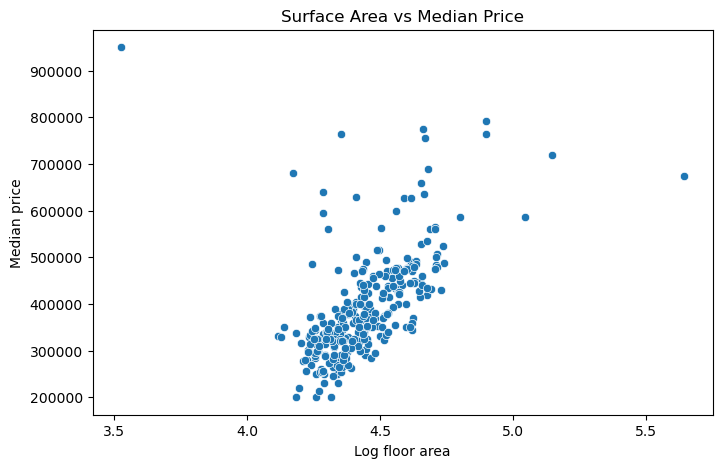

In [6]:
#how median price varies with average log floor area
plt.figure(figsize =(8,5))
sns.scatterplot(x = model['average_log_floor_area'], y = model['median_price'])
plt.title("Surface Area vs Median Price")
plt.xlabel("Log floor area")
plt.ylabel("Median price")
plt.show()

In [11]:
#Cluster of district based on median price and surface area
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
cluster = model[['postcode_district','median_price', 'average_log_floor_area']].dropna()
X = cluster[['median_price', 'average_log_floor_area']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster['cluster'] = kmeans.fit_predict(X_scaled)


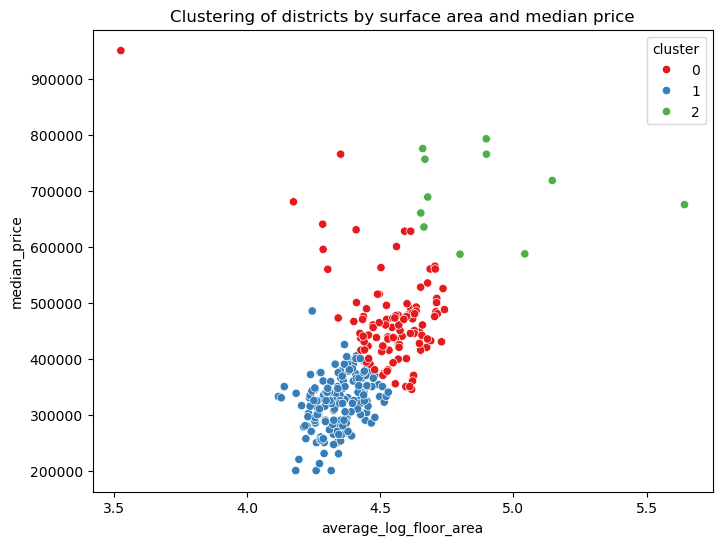

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster, x= 'average_log_floor_area', y = 'median_price', hue='cluster', palette ='Set1')
plt.title("Clustering of districts by surface area and median price")
plt.show()

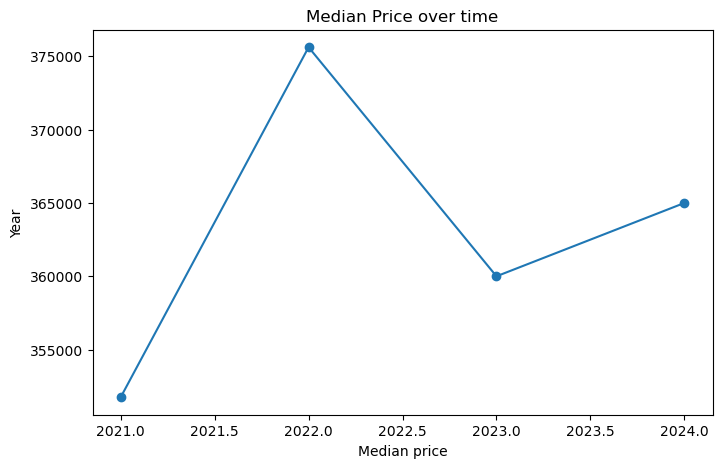

In [13]:
#Median price over time
trend = model.groupby('sale_year')['median_price'].median()
plt.figure(figsize =(8,5))
trend.plot(marker ="o")
plt.title("Median Price over time")
plt.xlabel("Median price")
plt.ylabel("Year")
plt.show()

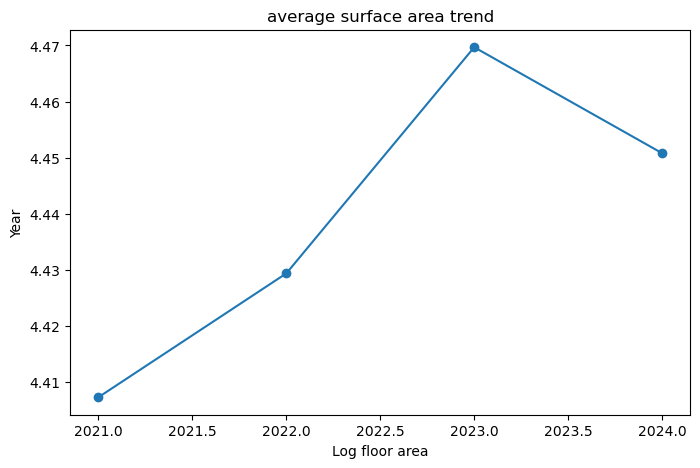

In [15]:
#Median price over time
area_trend = model.groupby('sale_year')['average_log_floor_area'].mean()
plt.figure(figsize =(8,5))
area_trend.plot(marker ="o")
plt.title("average surface area trend")
plt.xlabel("Log floor area")
plt.ylabel("Year")
plt.show()
#Surface area at 2023 is highest may mean that more large homes were sold during that time, 
#surface area started decreasing which may mean more inflation, affordability pressure. 

In [17]:
#proportion of each property type
model['pct_flat'] = model['epc_ptype_Flat']/ model['number_of_epc']
model['pct_house'] = model['epc_ptype_House']/ model['number_of_epc']
model['pct_bungalow'] = model['epc_ptype_Bungalow']/ model['number_of_epc']
model['pct_Maisonette'] = model['epc_ptype_Maisonette']/ model['number_of_epc']
model['pct_parkhome'] = model['epc_ptype_Park home']/ model['number_of_epc']
model['pct_large'] = model['percentage_of_large_property']

In [18]:
cluster_feature = model [['median_price','pct_flat','pct_house','pct_bungalow','pct_Maisonette','pct_parkhome','pct_large' ]]


In [19]:
scaler = StandardScaler()
x_property = scaler.fit_transform(cluster_feature)

In [20]:
kmeans = KMeans(n_clusters = 3,random_state = 42)
model['cluster_property_type'] = kmeans.fit_predict(x_property)

In [21]:
cluster_summary = model.groupby('cluster_property_type')[['median_price','pct_flat','pct_house','pct_bungalow','pct_Maisonette','pct_parkhome','pct_large' ]].mean()

In [22]:
print(cluster_summary)

                        median_price  pct_flat  pct_house  pct_bungalow  \
cluster_property_type                                                     
0                      376021.223404  0.001216   0.003896      0.001487   
1                      389917.810638  0.000332   0.002227      0.005052   
2                      728500.000000  0.000000   0.284722      0.020833   

                       pct_Maisonette  pct_parkhome  pct_large  
cluster_property_type                                           
0                            0.000110  7.756690e-07   0.009145  
1                            0.000026  4.259623e-03   0.006638  
2                            0.000000  0.000000e+00   0.111111  


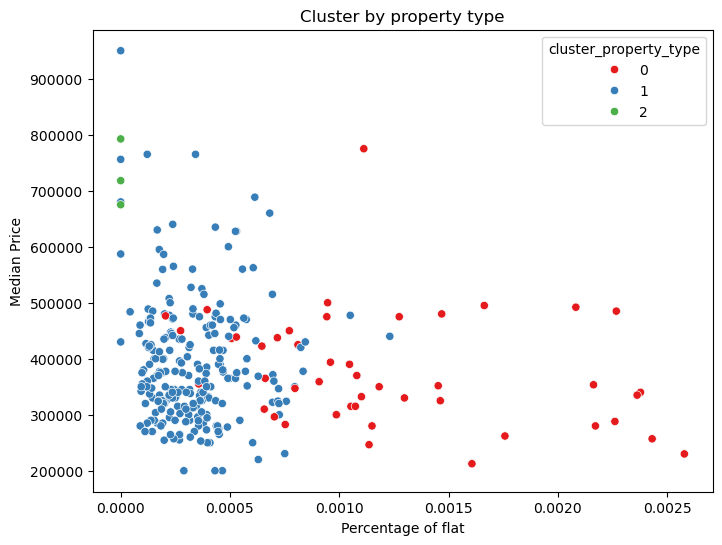

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=model['pct_flat'], y = model['median_price'], hue = model['cluster_property_type'],palette= 'Set1')
plt.title("Cluster by property type")
plt.xlabel("Percentage of flat")
plt.ylabel("Median Price")
plt.show()